# Ridge regression to avoid overfitting

In this notebook, we will reuse the polynomial regression notebook to see how ridge regularization fixes the problem. In particular, we will:

- Introduce ridge regression
- Compare overfitting vs regularization
- Observe the effect of the regularization parameter $\lambda$
- Select the optimal $\lambda$ using K-fold cross-validation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

### Generate synthetic data

In [2]:
np.random.seed(0)

N = 40  # small dataset to emphasize overfitting
# Input feature
X = np.linspace(0,1,N).reshape(-1, 1)
# Ground-truth target
y_true = np.sin(2 * np.pi * X[:, 0])
# Noisy observations
y = y_true + 0.25 * np.random.randn(N)

# Test data (dense grid)
X_test = np.linspace(0, 1, 200).reshape(-1, 1)
# Ground-truth target
y_test_true = np.sin(2 * np.pi * X_test[:, 0])

### Build polynomial features

In [3]:
# Using scikit-learn
degree = 10  # high degree to induce overfitting
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_poly = poly.fit_transform(X)
X_test_poly = poly.transform(X_test)

### Data normalization

Feature scaling is particularly important for ridge regression. Without notmalization, regularization would be inconsistent across variables.

In [4]:
scaler = StandardScaler()

X_poly_scaled = scaler.fit_transform(X_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

### Train models (least squares)

In [5]:
# Ordinary least squares (overfitting)
ols = LinearRegression()
ols.fit(X_poly_scaled, y)

# Ridge with different λ values (for comparison)
ridge_small = Ridge(alpha=1e-4) #λ=1e-4
ridge_medium = Ridge(alpha=1) #λ=1
ridge_large = Ridge(alpha=100) #λ=100

ridge_small.fit(X_poly_scaled, y)
ridge_medium.fit(X_poly_scaled, y)
ridge_large.fit(X_poly_scaled, y)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

### Predictions

In [6]:
y_ols = ols.predict(X_test_poly_scaled)

y_ridge_small = ridge_small.predict(X_test_poly_scaled)
y_ridge_medium = ridge_medium.predict(X_test_poly_scaled)
y_ridge_large = ridge_large.predict(X_test_poly_scaled)

### Comparison plot

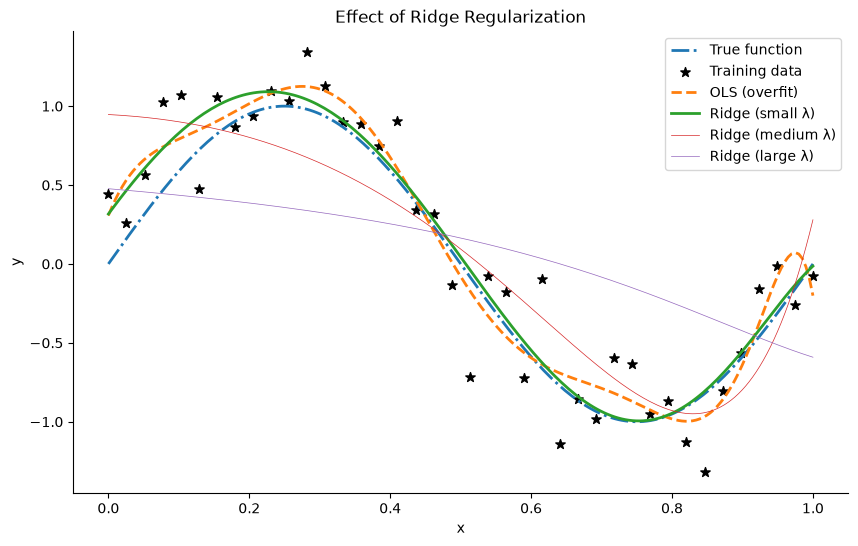

In [7]:
plt.figure(figsize=(10, 6))

# True function
plt.plot(X_test, y_test_true, '-.', linewidth=2, label="True function", ms=2)

# Training data
plt.scatter(X, y, marker='*', s=50, color='k', label="Training data")

# Models
plt.plot(X_test, y_ols, '--', linewidth=2, label="OLS (overfit)")
plt.plot(X_test, y_ridge_small, linewidth=2, label="Ridge (small λ)")
plt.plot(X_test, y_ridge_medium, linewidth=0.5, label="Ridge (medium λ)")
plt.plot(X_test, y_ridge_large, linewidth=0.5, label="Ridge (large λ)")

plt.legend()
plt.title("Effect of Ridge Regularization")
plt.xlabel("x")
plt.ylabel("y")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Error analysis

In [8]:
# Dictionary of model predictions
models = {
    "OLS": y_ols,
    "Ridge small λ": y_ridge_small,
    "Ridge medium λ": y_ridge_medium,
    "Ridge large λ": y_ridge_large
}

# Compute the mean squarred error for each model
print("Test MSE:\n")
for name, y_pred in models.items():
    mse = mean_squared_error(y_test_true, y_pred)
    print(f"{name}: {mse:.3f}")

Test MSE:

OLS: 0.023
Ridge small λ: 0.013
Ridge medium λ: 0.085
Ridge large λ: 0.272


### Effect of regularization on the amplitude of parameters

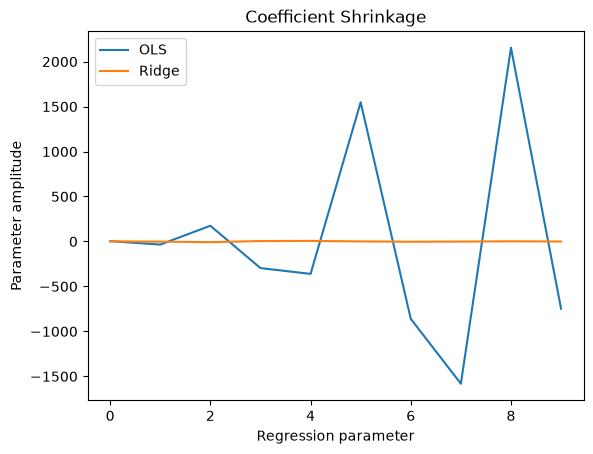

In [9]:
plt.plot(ols.coef_.ravel(), label="OLS")
plt.plot(ridge_small.coef_.ravel(), label="Ridge")
plt.legend()
plt.title("Coefficient Shrinkage")
plt.xlabel("Regression parameter")
plt.ylabel("Parameter amplitude")
plt.show()

### Results interpretation:

- The OLS model (no regularization) fits the training data almost perfectly but shows strong oscillations (overfitting)
- Ridge regression smooths the solution by shrinking the model parameters
- This biases the approximation, but improves generalization
- The regularization parameter $\lambda$ controls the bias-variance trade-off
- Large $\lambda$ results in underfitting

### Cross-validation for selecting $\lambda$

Cross-validation provides an estimate of the generalization error that we can use to select λ in a data-driven fashion

In [10]:
# Define the range of interest for the lambda values (log-scale)
lambdas = np.logspace(-4, 0, 50)

# Number of folds
K = 10
# Cross-validator object
kf = KFold(n_splits=K, shuffle=True, random_state=0)

# Store average validation errors
cv_errors = []

# Loop over the lambda values to assess 
for alpha in lambdas:

    # Store errors for the current validation folds
    fold_errors = []

    # Get a different pair of training and validation indices at every iteration
    for train_idx, val_idx in kf.split(X_poly_scaled):
        
        # Split data
        X_train_cv = X_poly_scaled[train_idx]
        y_train_cv = y[train_idx]
        X_val_cv = X_poly_scaled[val_idx]
        y_val_cv = y[val_idx]
        
        # Train ridge model for the current lambda value
        model = Ridge(alpha=alpha)
        model.fit(X_train_cv, y_train_cv)
        
        # Predict on validation fold
        y_val_pred = model.predict(X_val_cv)
        
        # Compute and store the validation error
        mse = mean_squared_error(y_val_cv, y_val_pred)
        fold_errors.append(mse)
    
    # Store average validation error across folds
    cv_errors.append(np.mean(fold_errors))

# Vector of average validation errors for the lambda values to assess
cv_errors = np.array(cv_errors)

### Plot cross-validation curve (CV error against $\lambda$)

The minimum corresponds to the best bias-variance trade-off

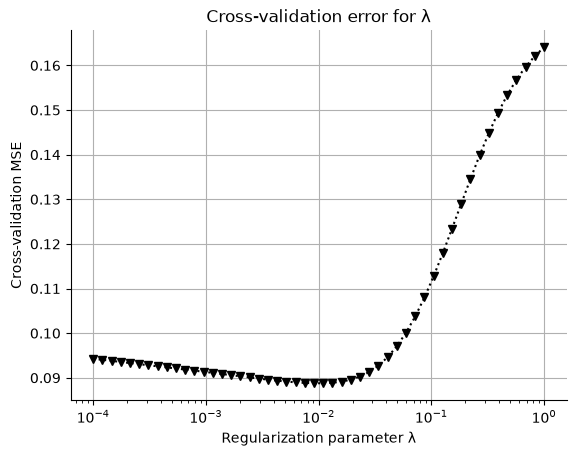

In [11]:
plt.figure()

plt.semilogx(lambdas, cv_errors, ':', c='k',marker='v',ms=6)
plt.xlabel("Regularization parameter λ")
plt.ylabel("Cross-validation MSE")
plt.title("Cross-validation error for λ")
plt.grid()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Select best $\lambda$

In [12]:
best_idx = np.argmin(cv_errors)
best_lambda = lambdas[best_idx]

print(f"Optimal lambda: {best_lambda:.4f}")

Optimal lambda: 0.0091


### Retrain and evaluate model for the optimal $\lambda$

In [13]:
ridge_opt = Ridge(alpha=best_lambda)
ridge_opt.fit(X_poly_scaled, y)

y_ridge_opt = ridge_opt.predict(X_test_poly_scaled)

### Comparison plot

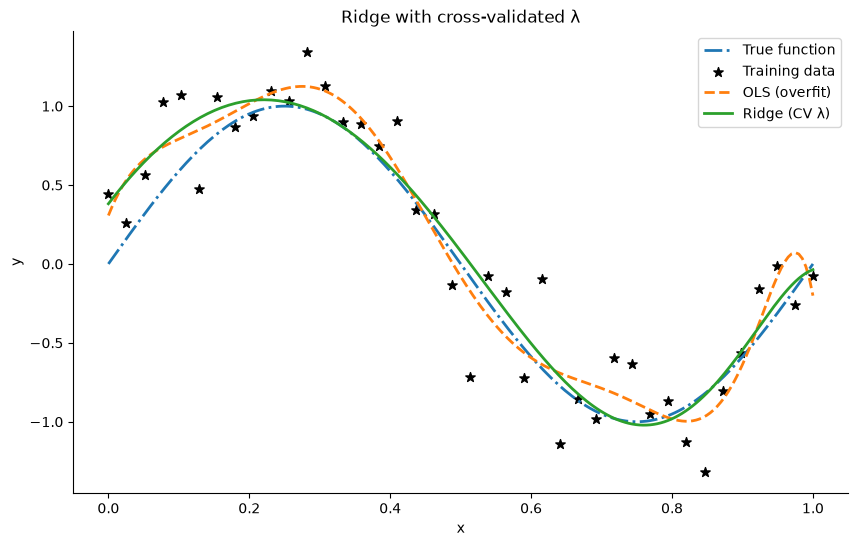

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(X_test, y_test_true, '-.',linewidth=2, label="True function", ms=2)
plt.scatter(X, y, marker='*', s=50, color='k', label="Training data")

plt.plot(X_test, y_ols, '--', linewidth=2, label="OLS (overfit)")
plt.plot(X_test, y_ridge_opt, label="Ridge (CV λ)", linewidth=2)

plt.legend()
plt.title("Ridge with cross-validated λ")
plt.xlabel("x")
plt.ylabel("y")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()